In [2]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv
Saving historical_data.csv to historical_data.csv


In [8]:
import pandas as pd
sentiment = pd.read_csv("fear_greed_index.csv")
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trader = pd.read_csv("historical_data.csv")
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
trader.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [11]:

sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [12]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [13]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [15]:
trader = trader.dropna()

In [16]:
sentiment = sentiment.drop_duplicates()


In [17]:
sentiment= sentiment.dropna()

In [21]:
trader['Date'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

In [23]:
sentiment['Date'] = pd.to_datetime(sentiment['date'], format='%Y-%m-%d').dt.date

In [24]:
data = pd.merge(trader, sentiment, on="Date")

In [26]:
data.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [28]:
data['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


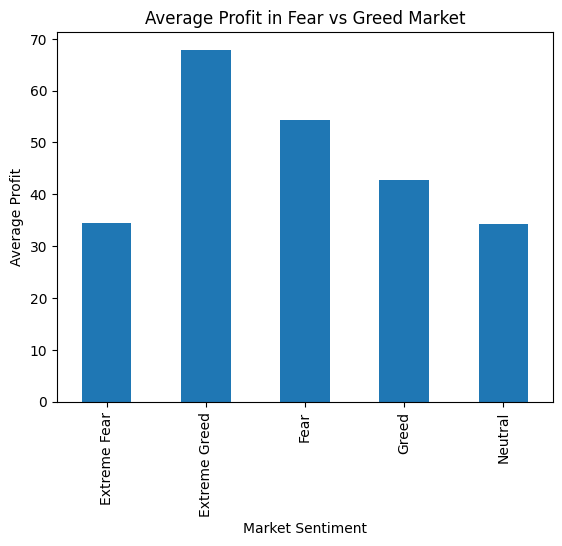

In [33]:
import matplotlib.pyplot as plt

avg_profit = data.groupby('classification')['Closed PnL'].mean()

avg_profit.plot(kind='bar')
plt.title("Average Profit in Fear vs Greed Market")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Profit")
plt.show()

 Insights:

Positive market sentiment (Greed) supports profitable trades, while negative sentiment (Fear) makes trading risky and reduces average profit.


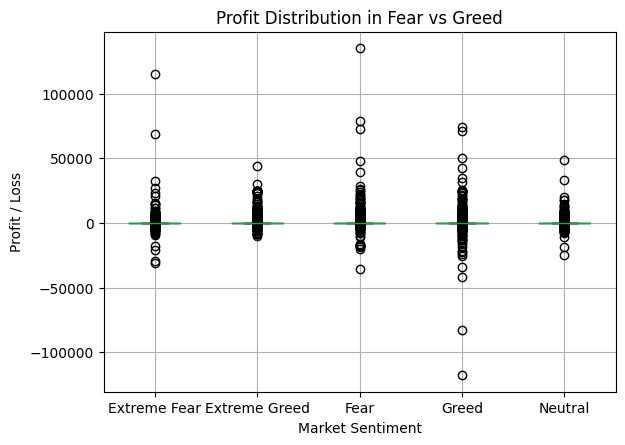

In [36]:
data.boxplot(column='Closed PnL', by='classification')
plt.title("Profit Distribution in Fear vs Greed")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Profit / Loss")
plt.show()

Insights

Fear market condition shows higher chance of big loss or big profit, while Greed market shows relatively balanced trading performance.

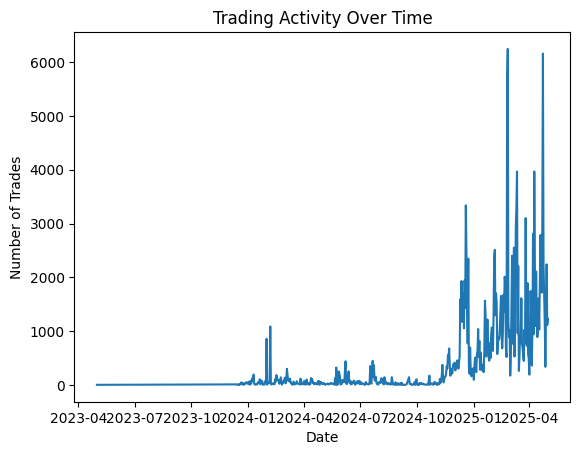

In [37]:
trades_per_day = data.groupby('Date').size()

trades_per_day.plot()
plt.title("Trading Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.show()

Insights

The number of trades changes over time, showing that trader activity increases on some days and decreases on others depending on market conditions.

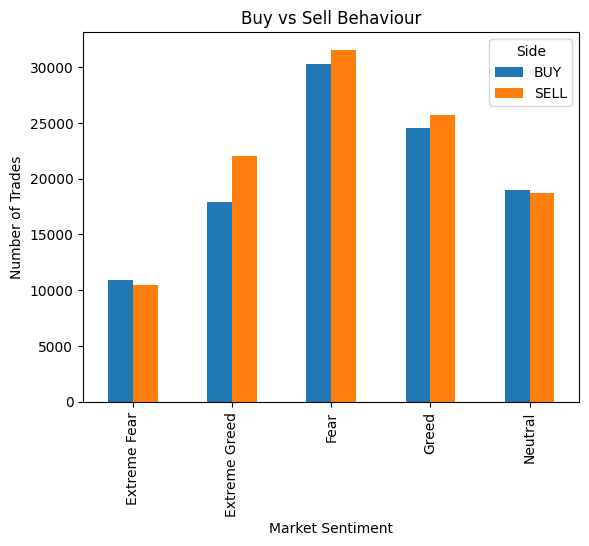

In [39]:
side_count = data.groupby(['classification','Side']).size().unstack()

side_count.plot(kind='bar')
plt.title("Buy vs Sell Behaviour")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

Insights

Market sentiment affects trading decisions — traders buy more in positive market mood and sell more in negative market mood.